###### libraries

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import dataframe_image as dfi

#setting pandas options
pd.set_option("display.max_columns", None) #columns
pd.set_option("display.max_rows", 10)      #rows

In [3]:
import sys

PROJECT_ROOT = Path.cwd().parents[1]

sys.path.append(str(PROJECT_ROOT))

In [4]:
import scripts.extra_features as EXTRA_FT
import scripts.models.xgboost as MODEL
import scripts.config as CONFIG

###### paths and files

In [30]:
IMAGES_DIR = PROJECT_ROOT / 'images/models'

In [31]:
IMAGES_DIR

WindowsPath('c:/Users/bruno/Documents/OneDrive/cursos e estudos/pós graduação/módulos/TCC/desenvolvimento/github/flight-delay-prediction/images/models')

In [5]:
flights_featured = pd.read_csv(PROJECT_ROOT/CONFIG.FEATURED_DATASET_PATH)

#### model fit

In [6]:
X = flights_featured[CONFIG.PREDICTOR_LIST]
y = flights_featured[CONFIG.TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=CONFIG.TEST_SIZE, random_state=CONFIG.RANDOM_STATE)

#original columns
original_cols = X_train.columns.tolist()

#### adding new features

In [7]:
#route delay rate
X_train, X_test = EXTRA_FT.add_route_delay_rate(X_train, X_test, y_train, CONFIG.TARGET, EXTRA_FT.MIN_FLIGHTS)

#origin delay rate
X_train, X_test = EXTRA_FT.add_delay_rate_feature(X_train, X_test, y_train, CONFIG.TARGET, group_column="ORIGIN", feature_name="origin_delay_rate")

#destination delay rate
X_train, X_test = EXTRA_FT.add_delay_rate_feature(X_train, X_test, y_train, CONFIG.TARGET, group_column="DEST", feature_name="dest_delay_rate")

#airline delay rate
X_train, X_test = EXTRA_FT.add_delay_rate_feature(X_train, X_test, y_train, CONFIG.TARGET, group_column="AIRLINE_CODE", feature_name="airline_delay_rate")

#departure congestion
X_train, X_test = EXTRA_FT.add_departure_congestion(X_train, X_test, 30, "normalized")

#new numerical features
new_numerical_features = [col for col in X_train.columns if col not in original_cols]

#### encoding

In [8]:
#ordinal encoder
ord_enc = OrdinalEncoder(categories=[['Very Short Haul', 'Short Haul', 'Medium Haul', 'Long Haul']])

#onehot encoder
oh_enc = OneHotEncoder(handle_unknown='ignore')

#standard scaler
ss_enc = StandardScaler()

#column transformer
col_tran = ColumnTransformer([("nominal", oh_enc, CONFIG.NOMINAL_FEATURES),
                              ("numerical", ss_enc, CONFIG.NUMERICAL_FEATURES + new_numerical_features),
                              ("ordinal", ord_enc, CONFIG.ORDINAL_FEATURES)])

#fitting and transforming
X_train_tran = col_tran.fit_transform(X_train)

X_test_tran = col_tran.transform(X_test)

#### model run

In [9]:
#xgboost
unbalanced_weight = MODEL.unbalanced_classes(y_train)

model = MODEL.train(X_train_tran, y_train, unbalanced_weight, CONFIG.RANDOM_STATE)

y_pred = model.predict(X_test_tran)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

c:\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [04:36:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.89      0.68      0.77    475861
           1       0.30      0.61      0.40    106756

    accuracy                           0.67    582617
   macro avg       0.59      0.65      0.59    582617
weighted avg       0.78      0.67      0.70    582617

[[323677 152184]
 [ 41260  65496]]


#### shap analysis

##### encoded features

In [10]:
#explainer
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_tran)

In [11]:
#importance dataframe
importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({"feature": col_tran.get_feature_names_out(), "importance": importance})
importance_df["feature"] = (importance_df["feature"].str.replace("nominal__", "", regex=False).str.replace("numerical__", "", regex=False).str.replace("ordinal__", "", regex=False))

In [12]:
importance_df.sort_values("importance", ascending=True)

,feature,importance
462,DEST_CDV,0.000000
562,DEST_HTS,0.000000
359,ORIGIN_STC,0.000000
352,ORIGIN_SLN,0.000000
571,DEST_ILG,0.000000
...,...,...
914,DISTANCE,0.213888
913,CRS_ELAPSED_TIME,0.224072
920,route_delay_rate,0.234195
917,year,0.255982


In [13]:
importance_df.sort_values("importance", ascending=True).tail(10)

,feature,importance
909,season_Fall,0.069128
916,crs_arrival_minutes,0.079513
911,season_Summer,0.090898
918,month,0.092068
923,airline_delay_rate,0.094896
914,DISTANCE,0.213888
913,CRS_ELAPSED_TIME,0.224072
920,route_delay_rate,0.234195
917,year,0.255982
915,crs_departure_minutes,0.297454


##### original features

In [14]:
#collecting original features
aggregated = []

#nominal features
for feature in CONFIG.NOMINAL_FEATURES:
    mask = importance_df["feature"].str.startswith(feature + "_")
    aggregated.append({"feature": feature, "importance": importance_df.loc[mask, "importance"].sum()})

#unchanged features
remaining = importance_df[~importance_df["feature"].str.contains("^(" + "|".join(CONFIG.NOMINAL_FEATURES) + ")_", regex=True)]

#concatenate
importance_grouped = pd.concat([remaining, pd.DataFrame(aggregated)], ignore_index=True)

importance_grouped = importance_grouped.sort_values("importance", ascending=False).reset_index(drop=True)

C:\Users\bruno\AppData\Local\Temp\ipykernel_33884\1492086197.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  remaining = importance_df[~importance_df["feature"].str.contains("^(" + "|".join(CONFIG.NOMINAL_FEATURES) + ")_", regex=True)]


In [15]:
pd.set_option("display.max_rows", 24)
importance_grouped

,feature,importance
0,crs_departure_minutes,0.297454
1,year,0.255982
2,route_delay_rate,0.234195
3,season,0.228898
4,CRS_ELAPSED_TIME,0.224072
5,DISTANCE,0.213888
6,day_of_week,0.151115
7,AIRLINE_CODE,0.142179
8,airline_delay_rate,0.094896
9,DEST,0.092846


##### plots and tables

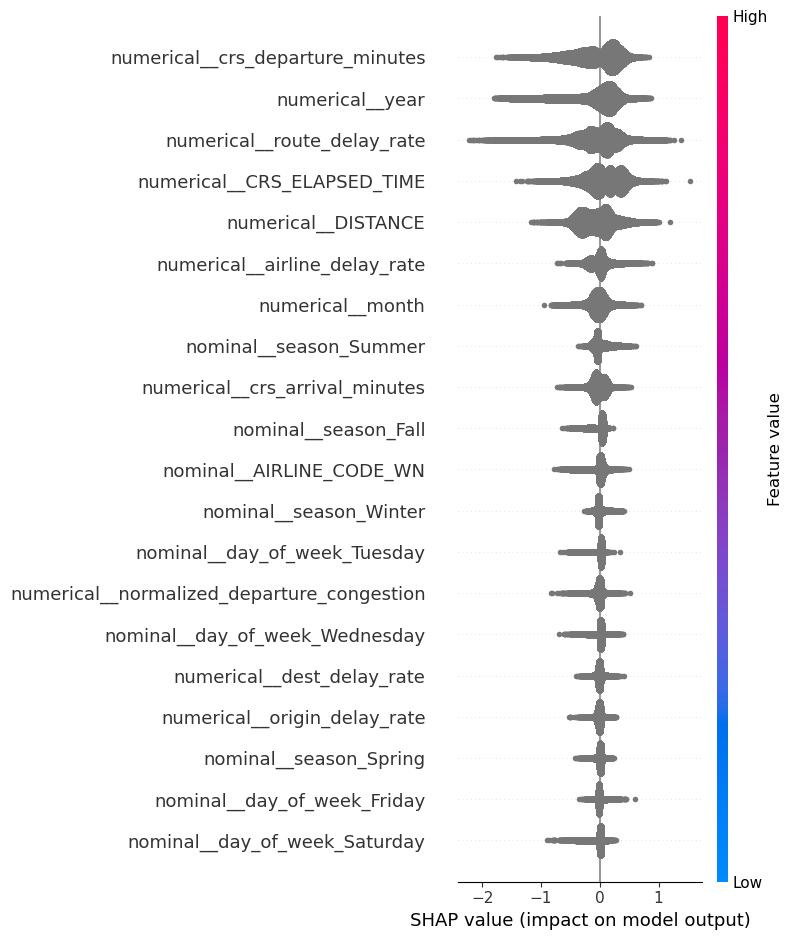

In [36]:
#summary plot
shap.summary_plot(shap_values, X_test_tran, feature_names=col_tran.get_feature_names_out(), show=False)

plt.tight_layout()

#save the figure
plt.savefig(IMAGES_DIR / "summary_plot.png", dpi=300, bbox_inches="tight")

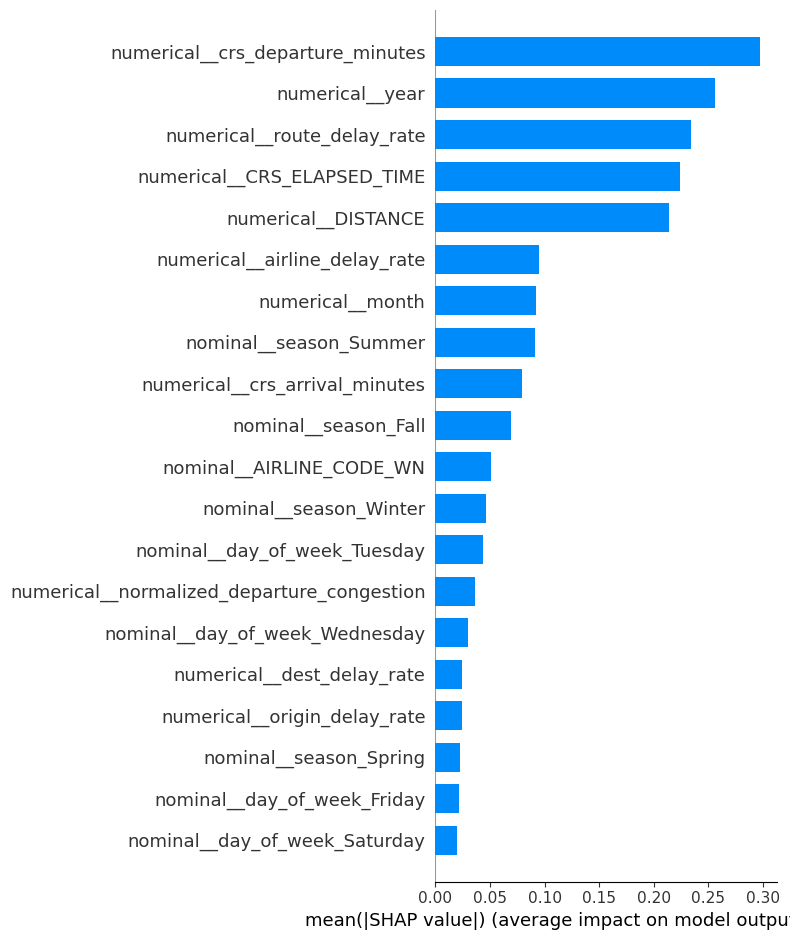

In [37]:
shap.summary_plot(shap_values, X_test_tran, feature_names=col_tran.get_feature_names_out(),
                  plot_type="bar", show=False)

plt.tight_layout()

#save the figure
plt.savefig(IMAGES_DIR / "summary_plot_bar.png", dpi=300, bbox_inches="tight")

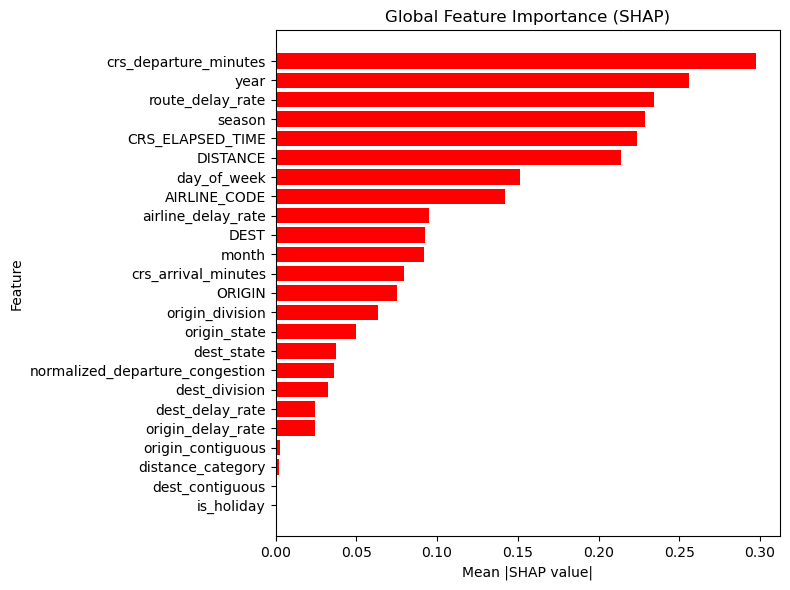

<Figure size 640x480 with 0 Axes>

In [38]:
#grouped feature importance
plot_df = importance_grouped.sort_values("importance")

#plot
plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"], color="red")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Global Feature Importance (SHAP)")

#show figure
plt.tight_layout()
plt.show()

#save the figure
plt.savefig(IMAGES_DIR / "feature_imnportance.png", dpi=300, bbox_inches="tight")

In [40]:
feature_table = importance_grouped.style.hide(axis="index").format({"importance": "{:.6f}"})
dfi.export(feature_table, IMAGES_DIR / 'feature_imnportance_table.png')
feature_table

feature,importance
crs_departure_minutes,0.297454
year,0.255982
route_delay_rate,0.234195
season,0.228898
CRS_ELAPSED_TIME,0.224072
DISTANCE,0.213888
day_of_week,0.151115
AIRLINE_CODE,0.142179
airline_delay_rate,0.094896
DEST,0.092846
